<img src="images/banner.png" style="width: 100%;">

# Introduction to Keras

Keras is a deep learning API for Python that provides a convenient way to define and
train any kind of deep learning model. 

In [3]:
# %pip install tensorflow

In [1]:
import keras
from keras import layers
from keras import ops


from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 14,
                 'axes.titlesize': 16, 'axes.titleweight': 'bold',
                 'lines.linewidth': 3})

## Setup the Backend Framework

Since no backend was specified, you will be running on top of the default backend, Tensorflow.

Otherwise, you should set the enivornment variable `KERAS_BACKEND` first prior to importing `keras`.

##  Define the Model Architecture

### Layers

- https://keras.io/api/layers/

The fundamental data structure in neural networks is the **layer**. A **layer** is a data processing module that takes as input one or more tensors and that outputs one or more tensors.

Some layers are stateless, but more frequently, layers have a state: the layer's **weights**, one or several tensors learned with stochastic gradient descent, which together contain the network's knowledge.

Different types of layers are appropriate for different tensor formats and different types of data processing.

In [2]:
from keras import layers

#### Dense Layer

This is your regular densely-connected neural network layer.

```python
keras.layers.Dense(
    units,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    lora_rank=None,
    lora_alpha=None,
    quantization_config=None,
    **kwargs
)
```

In [3]:
layer = layers.Dense(32, activation='relu')
layer

<Dense name=dense, built=False>

### Model
- https://keras.io/api/models/model/

#### Functional API
- https://keras.io/guides/functional_api/

The functional API can handle models with non-linear topology, shared layers, and even multiple inputs or outputs.

The main idea is that a deep learning model is usually a directed acyclic graph (DAG) of layers. So the functional API is a way to build graphs of layers.

With the Functional API, you start from Input, you chain layer calls to specify the model's forward pass, and finally, you create your model from inputs and outputs:

In [4]:
inputs = keras.Input(shape=(37,))
x = keras.layers.Dense(32, activation="relu")(inputs)
outputs = keras.layers.Dense(5, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

#### Sequential API
- https://keras.io/guides/sequential_model/

With the Sequential API, the model is purely a stack of single-input, single-output layers. 

A Sequential model is appropriate for a plain stack of layers where **each layer has exactly one input tensor and one output tensor**.

A Sequential model is not appropriate when:

- Your model has multiple inputs or multiple outputs.
- Any of your layers has multiple inputs or multiple outputs.
- You need to do layer sharing.
- You want non-linear topology (e.g. a residual connection, a multi-branch model).

In [5]:
model = keras.Sequential([
    keras.Input(shape=(None, None, 3)),
    keras.layers.Conv2D(filters=32, kernel_size=3),
    keras.layers.Dense(2, activation="relu"),
])

Its layers are accessible via the layers attribute:

In [6]:
model.layers

[<Conv2D name=conv2d, built=True>, <Dense name=dense_3, built=True>]

You can also create Sequential model incrementally via the `add()` method:

In [7]:
model = keras.Sequential()
model.add(layers.Dense(2, activation="relu"))
model.add(layers.Dense(3, activation="relu"))
model.add(layers.Dense(4))

## Configure the learning process

Once the model architecture is defined, you still have to choose three more things:

1. Loss function (objective function)
    - The quantity that will be minimized during training.
    - It represents a measure of success for the task at hand.
    - Examples: `CategoricalCrossEntropy()`, `MeanSquaredError()`
    - https://keras.io/api/losses/
2. Optimizer
    - This determines how the network will be updated based on the loss function.
    - It implements a specific variant of stochastic gradient descent (SGD).
    - Examples: `SGD`, `RMSProp()`, Adam()`
    - https://keras.io/api/optimizers/
3. Metrics
    - The measures of success you want to monitor during training and validation.
    - Unlike the loss function, training will not optimize directly for these metrics.
    - https://keras.io/api/metrics/


Once you've picked your loss function, optimizer and metrics, you can use the built-in `compile()` and `fit` methods to start training your model.

The **`compile()`** method configures the training process. 
```python
Model.compile(
    optimizer="rmsprop",
    loss=None,
    loss_weights=None,
    metrics=None,
    weighted_metrics=None,
    run_eagerly=False,
    steps_per_execution=1,
    jit_compile="auto",
    auto_scale_loss=True,
)


In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(),
        keras.metrics.FalseNegatives(),
    ],
)

The **`fit()`** method implements the triaing loop itself.

```python
Model.fit(
    x=None,
    y=None,
    batch_size=None,
    epochs=1,
    verbose="auto",
    callbacks=None,
    validation_split=0.0,
    validation_data=None,
    shuffle=True,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1,
)


## Evaluate the model

The **`evaluate()`** method returns the loss value and metrics values for the model in test mode.

```python
    Model.evaluate(
    x=None,
    y=None,
    batch_size=None,
    verbose="auto",
    sample_weight=None,
    steps=None,
    callbacks=None,
    return_dict=False,
    **kwargs
)


# Other Resources

- [Developer guides](https://keras.io/guides/)
- [Keras 3 API documentation](https://keras.io/api/)
- [Code Examples](https://keras.io/examples/)

<img src="images/banner-down.png" style="width: 100%;">

https://keras.io/examples/vision/mnist_convnet/

In [11]:
import numpy as np
import keras
from keras import layers

In [12]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


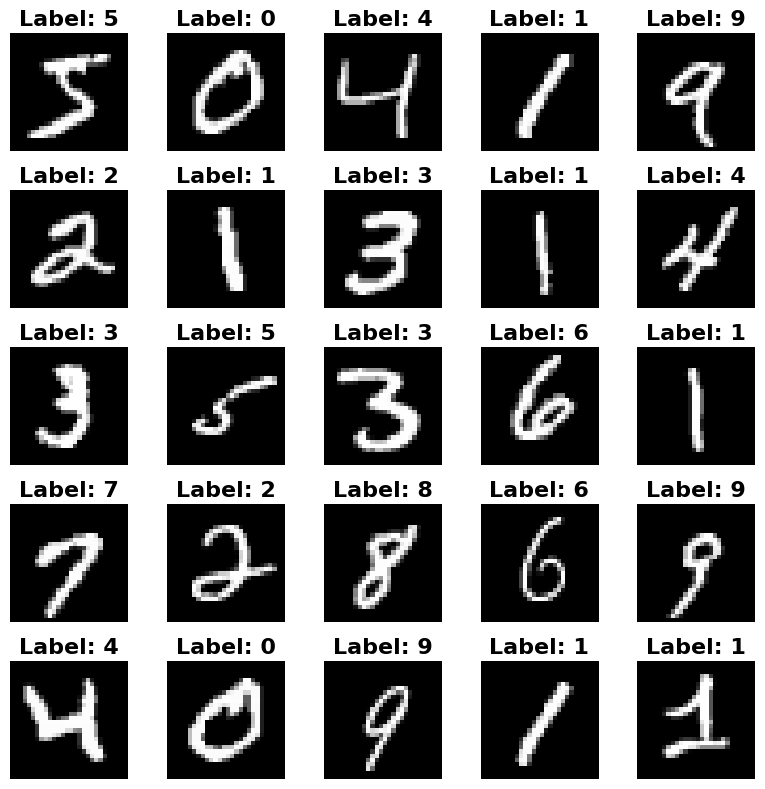

In [14]:
import matplotlib.pyplot as plt

# Plot a grid of 25 samples
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {y_train[i].argmax()}")  # argmax because labels are one-hot encoded
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8887 - loss: 0.3626 - val_accuracy: 0.9787 - val_loss: 0.0809
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9657 - loss: 0.1098 - val_accuracy: 0.9843 - val_loss: 0.0559
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9740 - loss: 0.0839 - val_accuracy: 0.9873 - val_loss: 0.0483
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9788 - loss: 0.0693 - val_accuracy: 0.9882 - val_loss: 0.0417
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9805 - loss: 0.0620 - val_accuracy: 0.9903 - val_loss: 0.0385
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9830 - loss: 0.0550 - val_accuracy: 0.9905 - val_loss: 0.0373
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9834 - loss: 0.0509 - val_accuracy: 0.9897 - val_loss: 0.0349
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9860 - loss: 0.0471 - val_accuracy: 0.

In [17]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.023067211732268333
Test accuracy: 0.992900013923645


In [28]:
# If needed once:
# %pip install ipycanvas

import numpy as np
from PIL import Image
import io
import ipywidgets as widgets
# from IPython.display import display
from IPython.display import display, HTML
from ipycanvas import Canvas

# --- UI ---
# canvas = Canvas(width=280, height=280)
canvas = Canvas(width=280, height=280, sync_image_data=True)
output = widgets.Output()
btn_predict = widgets.Button(description="Predict", button_style="primary")
btn_clear = widgets.Button(description="Clear")

# --- drawing state ---
drawing = {"active": False}

def reset_canvas():
    canvas.fill_style = "black"
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.stroke_style = "white"
    canvas.line_width = 18
    canvas.line_cap = "round"
    canvas.line_join = "round"

reset_canvas()

def on_mouse_down(x, y):
    drawing["active"] = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if not drawing["active"]:
        return
    canvas.line_to(x, y)
    canvas.stroke()

def on_mouse_up(x, y):
    drawing["active"] = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def on_clear(_):
    reset_canvas()
    with output:
        output.clear_output(wait=True)
        print("Canvas cleared.")

def on_predict(_):
    # RGBA array: (H, W, 4)
    rgba = np.array(canvas.get_image_data(0, 0, canvas.width, canvas.height), dtype=np.uint8)

    # white strokes on black bg -> use red channel as grayscale
    gray = rgba[:, :, 0]

    img = Image.fromarray(gray, mode="L").resize((28, 28), Image.LANCZOS)
    img_array = np.array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=(0, -1))  # (1, 28, 28, 1)

    preds = model.predict(img_array, verbose=0)
    digit = int(np.argmax(preds[0]))
    confidence = float(preds[0][digit] * 100)

    with output:
        output.clear_output(wait=True)
        # print(f"Predicted digit: {digit} ({confidence:.1f}%)")
        display(HTML(f"<div style='font-size:32px; font-weight:700;'>Predicted digit: {digit} ({confidence:.1f}%)</div>"))


btn_clear.on_click(on_clear)
btn_predict.on_click(on_predict)

display(widgets.HBox([btn_clear, btn_predict]))

display(canvas)
display(output)


Canvas(height=280, sync_image_data=True, width=280)

Output()